In [48]:

# ===============================
# 1️⃣ 라이브러리 불러오기
# ===============================
import pandas as pd
import numpy as np
import re
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 2️⃣ 데이터 불러오기
# ===============================
file_path =r"E:\BREAST1.csv"
file_path
df= pd.read_csv(file_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309044 entries, 0 to 309043
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Sex                     309044 non-null  object
 1   Age                     309044 non-null  object
 2   Race                    309044 non-null  object
 3   Marital status          309044 non-null  object
 4   ER                      309044 non-null  object
 5   HER2                    309044 non-null  object
 6   PR                      309044 non-null  object
 7   T/N/M Stage             309044 non-null  object
 8   Behavior code           309044 non-null  object
 9   Sequence number         309044 non-null  object
 10  Chemotherapy            309044 non-null  object
 11  Mets all                309044 non-null  object
 12  Mets at bone            309044 non-null  object
 13  Mets at brain           309044 non-null  object
 14  Mets at liver           309044 non-n

In [ ]:
# ===============================
# 전처리
# ===============================

# ===============================
#  target 
# ===============================

def _norm(s):
    s = unicodedata.normalize("NFKC", str(s))
    s = s.replace("\u00A0"," ").replace("\u2009"," ").replace("\u200A"," ").replace("\u2002"," ")
    s = re.sub(r"\s+"," ", s.strip().lower())
    return s

def to_target_from_behav(s):
    s0 = str(s)
    # 숫자코드 직접 대응
    if re.fullmatch(r"[0-3]", s0):
        return 1 if s0 == "3" else 0
    t = _norm(s0)
    if "malignant" in t:                # malignant, MALIGNANT 등
        return 1
    if re.search(r"in\s*[- ]?\s*situ|^cis$", t):   # in situ, in-situ, cis
        return 0
    # 두 값만 있다고 했으므로 나머지는 0으로 처리(원하면 np.nan)
    return 0

df = df_raw.copy()
if "Behavior code" not in df.columns:
    raise KeyError("Behavior code 컬럼이 없습니다. CSV 컬럼명을 확인하세요.")

df["target_bc"] = df["Behavior code"].map(to_target_from_behav).astype(int)

# sanity check
print("✅ target_bc 분포:", df["target_bc"].value_counts().to_dict())

# ---------------------------------------------
# 1) cancer treatment delay 전처리
# ---------------------------------------------
# Unable to calculate → 'Unknown' 치환
df['cancer treatment delay'] = df['cancer treatment delay'].replace('Unable to calculate', 'Unknown')


# 숫자로 변환 시도 (Unknown은 변환 안 됨 → NaN 처리)
df['cancer treatment delay_num'] = pd.to_numeric(df['cancer treatment delay'], errors='coerce')


# 구간별 라벨링 함수
def categorize_delay(x):
    if pd.isna(x):   # NaN → Unknown
        return 3
    elif 0 <= x <= 30:
        return 0
    elif 31 <= x <= 60:
        return 1
    elif x >= 61:
        return 2
    else:
        return 3   # 혹시 모를 예외 처리


# 라벨 컬럼 생성
df['cancer_delay_label'] = df['cancer treatment delay_num'].apply(categorize_delay)


# Unknown 반영 → 3으로 덮어쓰기
df.loc[df['cancer treatment delay'] == 'Unknown', 'cancer_delay_label'] = 3

# 3-1. 'Cancer Site' 제거
if 'Cancer Site' in df.columns:
    df = df.drop(columns=['Cancer Site'])



# 3-3. Race 그룹핑 (Unknown 포함)
df['Race_grouped'] = df['Race'].replace({
    'Unknown': 'Other (Unknown/AIAN)',
    'American Indian/Alaska Native': 'Other (Unknown/AIAN)'
})

# 3-4. Marital status 그룹핑
marital_map = {
    'Married (including common law)': 'Married',
    'Divorced': 'Previously Married',
    'Separated': 'Previously Married',
    'Widowed': 'Previously Married',
    'Never married': 'Single/Other',
    'Unknown': 'Single/Other',
    'Unmarried or Domestic Partner': 'Single/Other'
}
df['Marital_group'] = df['Marital status'].replace(marital_map)

# 3-5. Rural-Urban 그룹핑 (Unknown 유지)
def group_urban_rural_keep_unknown(x):
    if pd.isna(x) or 'Unknown/missing' in x:
        return 'Unknown'
    elif 'Large Metro' in x:
        return 'Large metro'
    elif 'metropolitan areas of' in x:
        return 'Small/Medium metro'
    else:
        return 'Rural'
df['Rural-Urban_grouped'] = df['Rural-Urban'].apply(group_urban_rural_keep_unknown)

# 3-6. Stage_Number 추출
def extract_stage_number(stage):
    match = re.search(r'\d', str(stage))
    return int(match.group()) if match else 0
df['Stage_Number'] = df['T/N/M Stage'].apply(extract_stage_number)

# 3-7. Surgery_Group 생성 (-1: 알 수 없음)
def surgery_group_safe(code):
    try:
        code_int = int(code)
    except:
        return -1
    if code_int == 0:
        return 0
    elif 10 <= code_int <= 39:
        return 1
    elif 40 <= code_int <= 69:
        return 2
    elif 70 <= code_int <= 80:
        return 3
    else:
        return -1
df['Surgery_Group'] = df['Surgery Prim Site'].apply(surgery_group_safe)

# 3-8. Surgery_Reg_Group 생성 (-1: 알 수 없음)
def surgery_other_group_safe(value):
    if value in ['0', 'None; diagnosed at autopsy']:
        return 0
    elif value in [
        'Non-primary surgical procedure performed',
        'Non-primary surgical procedure to other regional sites',
        'Non-primary surgical procedure to distant site',
        'Non-primary surgical procedure to distant lymph node(s)',
        'Any combo of sur proc to oth rg, dis lym nd, and/or dis site'
    ]:
        return 1
    else:
        return -1
df['Surgery_Reg_Group'] = df['Surgery Oth Reg/Dis'].apply(surgery_other_group_safe)

# 3-9. Sequence number 기반
df['One_vs_Other'] = df['Sequence number'].apply(lambda x: 1 if x == "One primary only" else 0)
def first_vs_later_safe(value):
    if value == 'One primary only':
        return -1
    elif value == '1st of 2 or more primaries':
        return 1
    else:
        return 0
df['First_vs_Later'] = df['Sequence number'].apply(first_vs_later_safe)

# 3-10. 주요 binary 컬럼 True/False -> 0/1
binary_cols = [
    'Sex','ER','PR','HER2','Radiation','Chemotherapy',
    'Mets at bone','Mets at brain','Mets at liver','Mets at lung','Survival months'
]
for col in binary_cols:
    df[col] = df[col].map(lambda x: 1 if 'Yes' in str(x) or 'Positive' in str(x) or 'Female' in str(x) or 'Malignant' in str(x) else 0)

# 3-11. Age ordinal 처리 (5세 단위 이미 묶음)
age_map = {cat: i for i, cat in enumerate(sorted(df['Age'].unique()))}
df['Age_ord'] = df['Age'].map(age_map)

# 3-12. Category 컬럼 처리
category_cols = ['Race_grouped','Marital_group','Income','Surgery_Group','Surgery_Reg_Group','Rural-Urban_grouped','cancer_delay_label']
for col in category_cols:
    df[col] = df[col].astype('category')

# 3-13. 최종 확인
print("Dataset shape:", df.shape)
print("Target distribution:\n", df['target'].value_counts())

✅ target_bc 분포: {1: 305214, 0: 3830}
Dataset shape: (309044, 37)
Target distribution:
 target
1    305214
0      3830
Name: count, dtype: int64


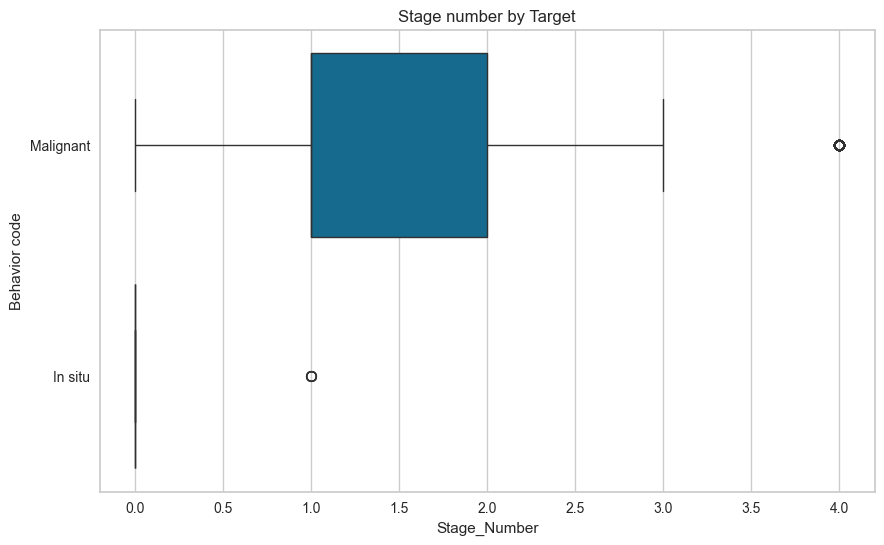

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

# 예시 데이터프레임: df
# 컬럼: 'Target', 'Stage', 'Studied_Credits'

plt.figure(figsize=(10,6))
sns.boxplot(
    x='Stage_Number',                # X축: Stage 번호 (int 또는 str)
    y='Behavior code',      # Y축: 공부한 학점 등 수치형
       # Target 별로 색상 분리
    data=df                   # 본인 데이터프레임
)
plt.title('Stage number by Target')
plt.show()



Before oversample: {1: 244171, 0: 3064}
After  oversample: {1: 244171, 0: 244171}
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 244171, number of negative: 244171
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010945 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 88
[LightGBM] [Info] Number of data points in the train set: 488342, number of used features: 20
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 50 rounds
[50]	training's auc: 0.999915	training's binary_logloss: 0.0437698	valid_1's auc: 0.99992	valid_1's binary_logloss: 0.0433206
[100]	training's auc: 0.999923	training's binary_logloss: 0.0051707

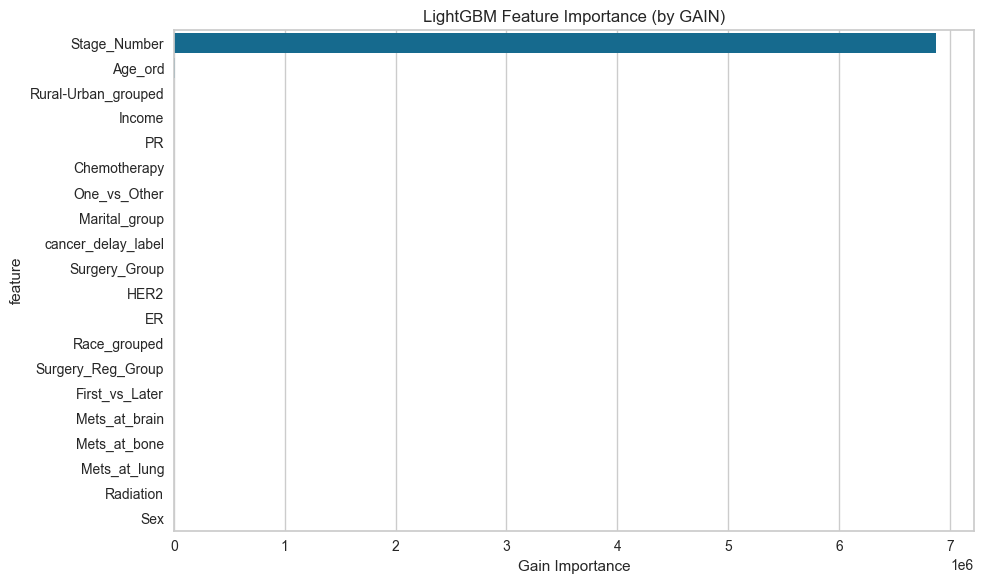

In [75]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, average_precision_score
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1) 피처 정의
num_cols = [c for c in ['Age_ord','Stage_Number'] if c in df.columns]
bin_cols = [c for c in [
    'Sex','ER','PR','HER2','Radiation','Chemotherapy',
    'Mets at bone','Mets at brain','Mets at liver','Mets at lung',
    'One_vs_Other','First_vs_Later'
] if c in df.columns]
cat_cols = [c for c in [
    'Race_grouped','Marital_group','Income',
    'Surgery_Group','Surgery_Reg_Group','Rural-Urban_grouped','cancer_delay_label'
] if c in df.columns]

feature_cols = num_cols + bin_cols + cat_cols

# 2) X, y 분리
X = df[feature_cols].copy()
y = df['target'].copy()

# 3) Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before oversample:", dict(y_train.value_counts()))

# 4) 오버샘플링 (학습셋만)
ros = RandomOverSampler(random_state=42)
X_tr_res, y_tr_res = ros.fit_resample(X_train, y_train)

print("After  oversample:", dict(pd.Series(y_tr_res).value_counts()))

###LightBGM 
# ===============================
# ===============================
# 5) LightGBM 학습
categorical_feature = [c for c in cat_cols if c in X_tr_res.columns]

lgbm = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

lgbm.fit(
    X_tr_res, y_tr_res,
    eval_set=[(X_tr_res, y_tr_res), (X_test, y_test)],
    eval_metric='auc',
    categorical_feature=categorical_feature,
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(50)]
)

# 6) 평가
y_pred = lgbm.predict(X_test)
y_proba = lgbm.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("PR AUC (Average Precision):", average_precision_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

# 7) Feature Importance
# 7') LightGBM 변수 중요도 (split & gain) + (옵션) SHAP
# ===============================
# split(기본) & gain 중요도 추출
split_imp = lgbm.feature_importances_
gain_imp  = lgbm.booster_.feature_importance(importance_type='gain')
feat_name = lgbm.booster_.feature_name()

imp_df = pd.DataFrame({
    'feature': feat_name,
    'split_importance': split_imp,
    'gain_importance': gain_imp
})

# 정규화 비율 추가
imp_df['split_pct'] = imp_df['split_importance'] / (imp_df['split_importance'].sum() + 1e-12)
imp_df['gain_pct']  = imp_df['gain_importance']  / (imp_df['gain_importance'].sum() + 1e-12)

# gain 기준 정렬
imp_sorted = imp_df.sort_values('gain_importance', ascending=False)

# === Top 20 Important Features 출력 ===
print("\n=== Top 20 Important Features (by GAIN) ===")
print(imp_sorted.head(20)[['feature','gain_importance','gain_pct','split_importance','split_pct']])

# 그래프 시각화 (gain 기준)
plt.figure(figsize=(10,6))
sns.barplot(data=imp_sorted.head(20), x='gain_importance', y='feature')
plt.title('LightGBM Feature Importance (by GAIN)')
plt.xlabel('Gain Importance')
plt.tight_layout()
plt.show()


=== Top 20 Important Features (by GAIN) ===
                feature  gain_importance  gain_pct  split_importance  \
1          Stage_Number     6.874690e+06  0.995759               356   
0               Age_ord     6.976067e+03  0.001010               834   
19  Rural-Urban_grouped     4.380772e+03  0.000635               432   
16               Income     4.036206e+03  0.000585               143   
4                    PR     2.997049e+03  0.000434               305   
7          Chemotherapy     2.545938e+03  0.000369               244   
12         One_vs_Other     2.168981e+03  0.000314               305   
15        Marital_group     2.029000e+03  0.000294               209   
20   cancer_delay_label     1.435582e+03  0.000208                48   
17        Surgery_Group     9.824461e+02  0.000142                28   
5                  HER2     8.969806e+02  0.000130               235   
3                    ER     4.336496e+02  0.000063               104   
14         Race_gro

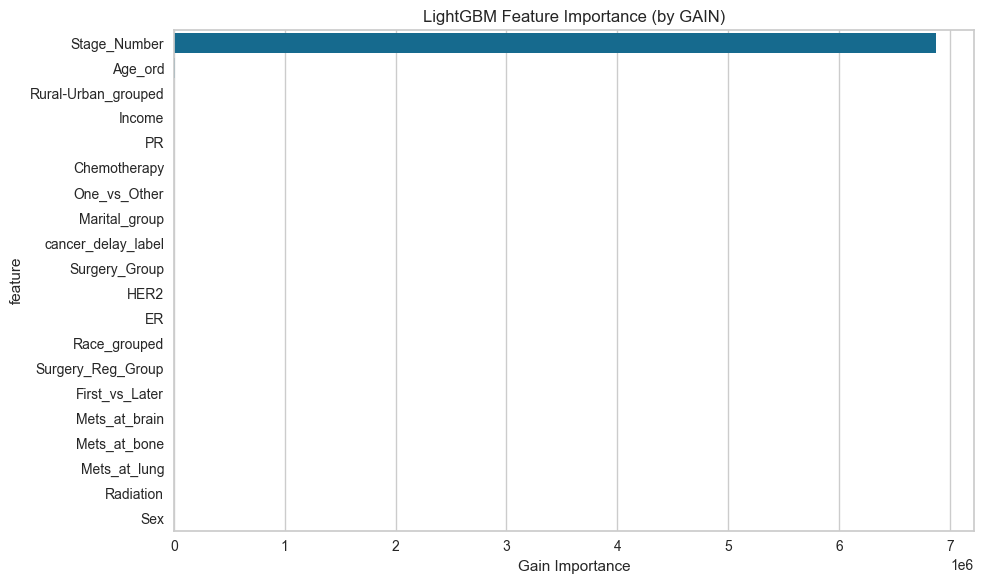

In [76]:
# 7) Feature Importance
# 7') LightGBM 변수 중요도 (split & gain) + (옵션) SHAP
# ===============================
# split(기본) & gain 중요도 추출
split_imp = lgbm.feature_importances_
gain_imp  = lgbm.booster_.feature_importance(importance_type='gain')
feat_name = lgbm.booster_.feature_name()

imp_df = pd.DataFrame({
    'feature': feat_name,
    'split_importance': split_imp,
    'gain_importance': gain_imp
})

# 정규화 비율 추가
imp_df['split_pct'] = imp_df['split_importance'] / (imp_df['split_importance'].sum() + 1e-12)
imp_df['gain_pct']  = imp_df['gain_importance']  / (imp_df['gain_importance'].sum() + 1e-12)

# gain 기준 정렬
imp_sorted = imp_df.sort_values('gain_importance', ascending=False)

# === Top 20 Important Features 출력 ===
print("\n=== Top 20 Important Features (by GAIN) ===")
print(imp_sorted.head(20)[['feature','gain_importance','gain_pct','split_importance','split_pct']])

# 그래프 시각화 (gain 기준)
plt.figure(figsize=(10,6))
sns.barplot(data=imp_sorted.head(20), x='gain_importance', y='feature')
plt.title('LightGBM Feature Importance (by GAIN)')
plt.xlabel('Gain Importance')
plt.tight_layout()
plt.show()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9997,0.9995,0.9997,1.0000,0.9998,0.9863,0.9864,1.1390
svm,SVM - Linear Kernel,0.9997,0.9994,0.9997,1.0000,0.9998,0.9860,0.9861,1.0460
ada,Ada Boost Classifier,0.9997,0.9994,0.9997,1.0000,0.9998,0.9863,0.9864,4.8640
ridge,Ridge Classifier,0.9759,0.9992,0.9756,1.0000,0.9876,0.4970,0.5748,0.9670
rf,Random Forest Classifier,0.9996,0.9992,0.9997,0.9999,0.9998,0.9845,0.9845,5.4980
gbc,Gradient Boosting Classifier,0.9997,0.9992,0.9997,1.0000,0.9998,0.9861,0.9862,12.1810
lda,Linear Discriminant Analysis,0.9759,0.9992,0.9756,1.0000,0.9876,0.4970,0.5748,1.8620
catboost,CatBoost Classifier,0.9997,0.9991,0.9997,1.0000,0.9998,0.9863,0.9864,21.8140
qda,Quadratic Discriminant Analysis,0.9995,0.9987,0.9997,0.9999,0.9998,0.9814,0.9815,1.6250
et,Extra Trees Classifier,0.9996,0.9980,0.9997,0.9999,0.9998,0.9818,0.9819,5.7780


=== Leaderboard (CV) ===
                                    Model  Accuracy     AUC  Recall   Prec.  \
lr                    Logistic Regression    0.9997  0.9995  0.9997  1.0000   
svm                   SVM - Linear Kernel    0.9997  0.9994  0.9997  1.0000   
ada                  Ada Boost Classifier    0.9997  0.9994  0.9997  1.0000   
ridge                    Ridge Classifier    0.9759  0.9992  0.9756  1.0000   
rf               Random Forest Classifier    0.9996  0.9992  0.9997  0.9999   
gbc          Gradient Boosting Classifier    0.9997  0.9992  0.9997  1.0000   
lda          Linear Discriminant Analysis    0.9759  0.9992  0.9756  1.0000   
catboost              CatBoost Classifier    0.9997  0.9991  0.9997  1.0000   
qda       Quadratic Discriminant Analysis    0.9995  0.9987  0.9997  0.9999   
et                 Extra Trees Classifier    0.9996  0.9980  0.9997  0.9999   

              F1   Kappa     MCC  TT (Sec)  
lr        0.9998  0.9863  0.9864     1.139  
svm       0.999

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9997,0.9999,0.9997,1.0000,0.9998,0.9869,0.9870
1,0.9997,0.9999,0.9997,1.0000,0.9999,0.9886,0.9886
2,0.9997,0.9999,0.9997,1.0000,0.9999,0.9886,0.9886
3,0.9997,0.9999,0.9997,1.0000,0.9999,0.9886,0.9886
4,0.9999,0.9999,0.9999,1.0000,0.9999,0.9951,0.9951
5,0.9995,0.9995,0.9995,1.0000,0.9997,0.9789,0.9790
6,0.9996,0.9998,0.9996,1.0000,0.9998,0.9837,0.9838
7,0.9996,0.9987,0.9997,1.0000,0.9998,0.9853,0.9853
8,0.9996,0.9999,0.9995,1.0000,0.9998,0.9821,0.9823


Fitting 10 folds for each of 10 candidates, totalling 100 fits

=== Hold-out Evaluation ===


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.9997,0.9999,0.9997,1.0000,0.9999,0.9882,0.9883


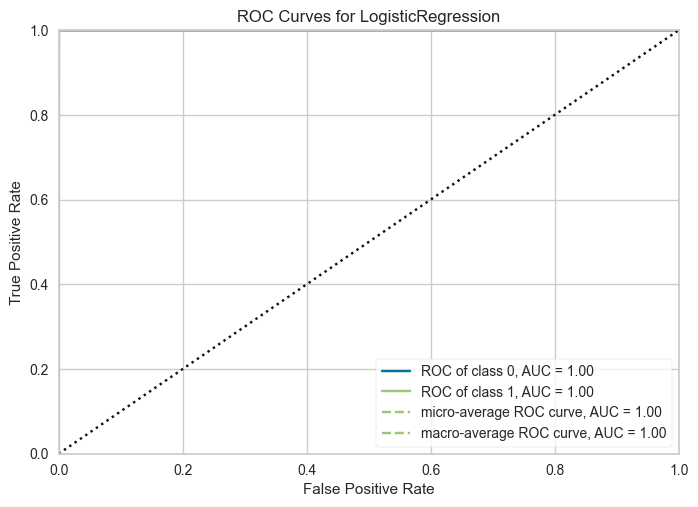

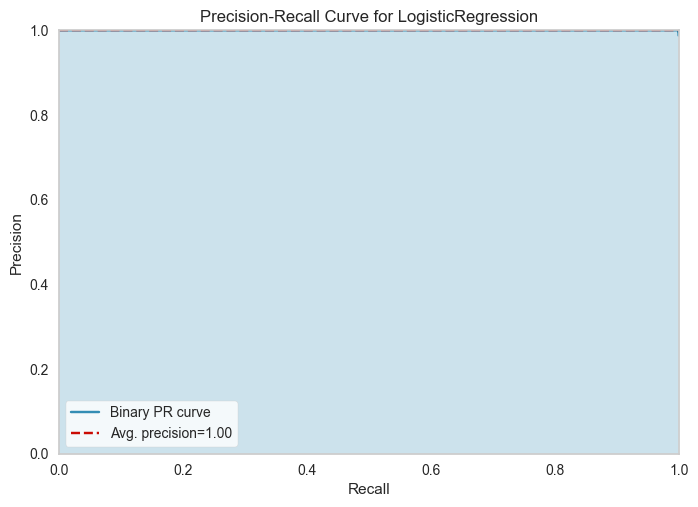

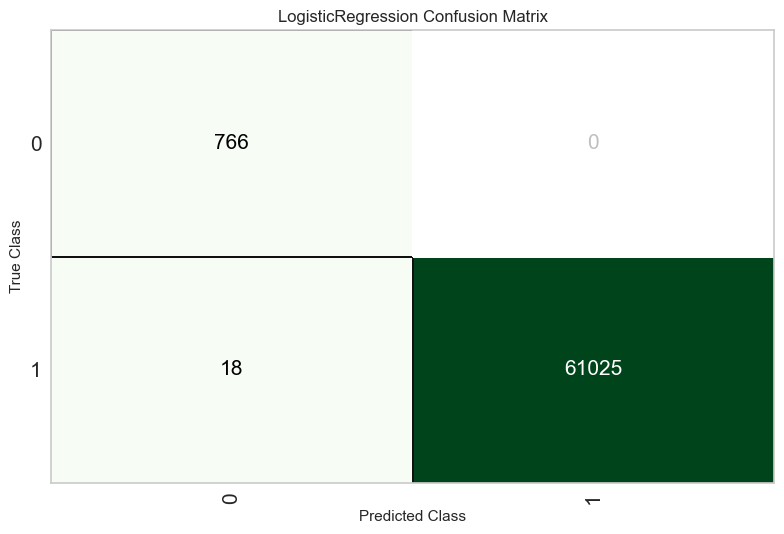

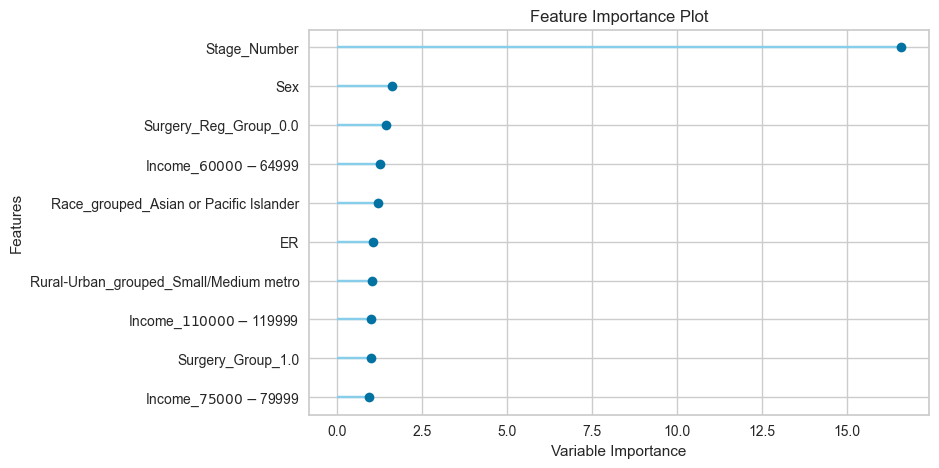

In [110]:
# ===============================
# 8️⃣ PyCaret Classification
# ===============================
from pycaret.classification import setup, compare_models, tune_model, finalize_model, predict_model, plot_model, pull

# 1) 데이터셋 준비
data_cls = df[feature_cols + ['target']].copy()

# 2) PyCaret 세팅
s = setup(
    data=data_cls,
    target='target',            # 종속변수
    session_id=42,              # 랜덤시드
    train_size=0.8,             # 8:2 분할
    fold=10,                    # 10-Fold 교차검증
    fold_strategy='stratifiedkfold',
    data_split_stratify=True,   # 클래스 비율 유지
    imputation_type='simple',   # 결측치 단순 대체
    numeric_imputation='median',
    categorical_imputation='most_frequent',
    remove_multicollinearity=True,
    multicollinearity_threshold=0.95,
    fix_imbalance=True,         # 클래스 불균형 자동 처리 (SMOTE 등)
    categorical_features=cat_cols,
    verbose=False)          

# 3) 여러 모델 비교 (AUC 기준 정렬)
best = compare_models(sort='AUC')

# 4) 리더보드 확인
leaderboard = pull()
print("=== Leaderboard (CV) ===")
print(leaderboard.head(10))

# ===============================
# 5) 베스트 모델 튜닝 및 최종화
best_tuned = tune_model(best, optimize='AUC')
final_best = finalize_model(best_tuned)

# 6) 홀드아웃셋 평가
print("\n=== Hold-out Evaluation ===")
predict_model(final_best)

# 7) 시각화
plot_model(final_best, plot='auc')                 # ROC 곡선
plot_model(final_best, plot='pr')                  # PR 곡선
plot_model(final_best, plot='confusion_matrix')    # 혼동 행렬
plot_model(final_best, plot='feature')             # 변수 중요도

Accuracy: 0.9997087802747173
ROC AUC: 0.9998755532043948
PR AUC (Average Precision): 0.999998449394828
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       766
           1       1.00      1.00      1.00     61043

    accuracy                           1.00     61809
   macro avg       0.99      1.00      0.99     61809
weighted avg       1.00      1.00      1.00     61809



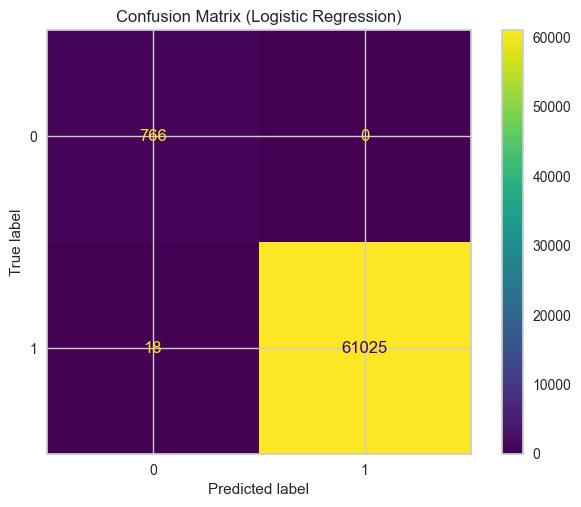


=== Top 20 Important Features (by |coef|) ===
                              feature       coef    odds_ratio      direction
1                        Stage_Number  16.536808  1.520004e+07    ↑ (risk up)
25           Income_$60,000 - $64,999  -1.738913  1.757113e-01  ↓ (risk down)
30           Income_$85,000 - $89,999   1.722795  5.600159e+00    ↑ (risk up)
32           Income_$95,000 - $99,999   1.659727  5.257874e+00    ↑ (risk up)
20                   Income_$120,000+   1.606305  4.984361e+00    ↑ (risk up)
31           Income_$90,000 - $94,999   1.561351  4.765253e+00    ↑ (risk up)
3                                  ER  -1.540817  2.142060e-01  ↓ (risk down)
27           Income_$70,000 - $74,999   1.363226  3.908781e+00    ↑ (risk up)
14                 Race_grouped_Black   1.351627  3.863706e+00    ↑ (risk up)
29           Income_$80,000 - $84,999   1.315198  3.725488e+00    ↑ (risk up)
18         Marital_group_Single/Other   1.194706  3.302586e+00    ↑ (risk up)
26           Inco

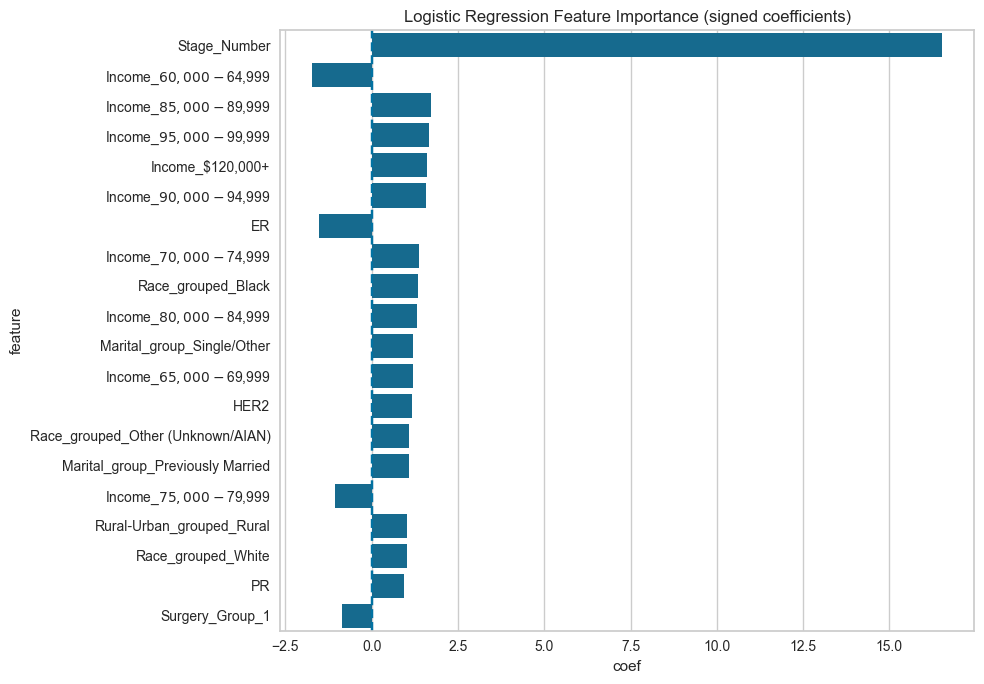

In [ ]:
# ===============================
# ===============================
## Logistic Regression 직접 구현 (Scikit-Learn)

# ===============================
# 1) 라이브러리
# ===============================
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, average_precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 2) 데이터 분리 (카테고리형 원-핫 인코딩)
# ===============================
X = pd.get_dummies(df[feature_cols], drop_first=True)
y = df['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# 3) 로지스틱 회귀 학습
# ===============================
lr = LogisticRegression(
    max_iter=2000,
    solver='saga',            # 대규모/희소행렬에 강함
    class_weight='balanced',  # 불균형 대응
    penalty='l2'              # 기본 L2 규제
)
lr.fit(X_train, y_train)

# ===============================
# 4) 예측 및 평가
# ===============================
y_pred  = lr.predict(X_test)
y_proba = lr.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("PR AUC (Average Precision):", average_precision_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

# 혼동행렬 
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix (Logistic Regression)')
plt.show()

# ===============================
# 5) 변수 중요도 (로지스틱 회귀 버전)
#    - coef_ 사용
#    - |coef| 기준 상위 특성
#    - odds ratio = exp(coef)
# ===============================
coef = lr.coef_.ravel()  # shape: (n_features,)
imp = (
    pd.DataFrame({
        'feature': X.columns,
        'coef': coef
    })
    .assign(
        abs_coef=lambda d: d['coef'].abs(),
        odds_ratio=lambda d: np.exp(d['coef']),
        direction=lambda d: np.where(d['coef'] >= 0, '↑ (risk up)', '↓ (risk down)')
    )
    .sort_values('abs_coef', ascending=False)
)

print("\n=== Top 20 Important Features (by |coef|) ===")
print(imp.head(20)[['feature', 'coef', 'odds_ratio', 'direction']])

# 시각화: 상위 20개, 계수부호 유지(양수=리스크↑, 음수=리스크↓)
topn = 20
plt.figure(figsize=(10, 7))
sns.barplot(
    data=imp.head(topn),
    x='coef', y='feature'
)
plt.axvline(0, linestyle='--')
plt.title('Logistic Regression Feature Importance (signed coefficients)')
plt.tight_layout()
plt.show()

Accuracy: 0.9994822760439418
ROC AUC: 0.9999021256641886
PR AUC (Average Precision): 0.9999987690836334
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       766
           1       1.00      1.00      1.00     61043

    accuracy                           1.00     61809
   macro avg       0.98      1.00      0.99     61809
weighted avg       1.00      1.00      1.00     61809


=== Top 20 Important Features ===
                                   feature  importance
1                             Stage_Number    0.849552
7                             Chemotherapy    0.075030
0                                  Age_ord    0.012942
5                                     HER2    0.009012
8                             Mets at bone    0.005746
3                                       ER    0.003831
13                          First_vs_Later    0.003464
4                                       PR    0.003199
16                      Race_grouped_Wh

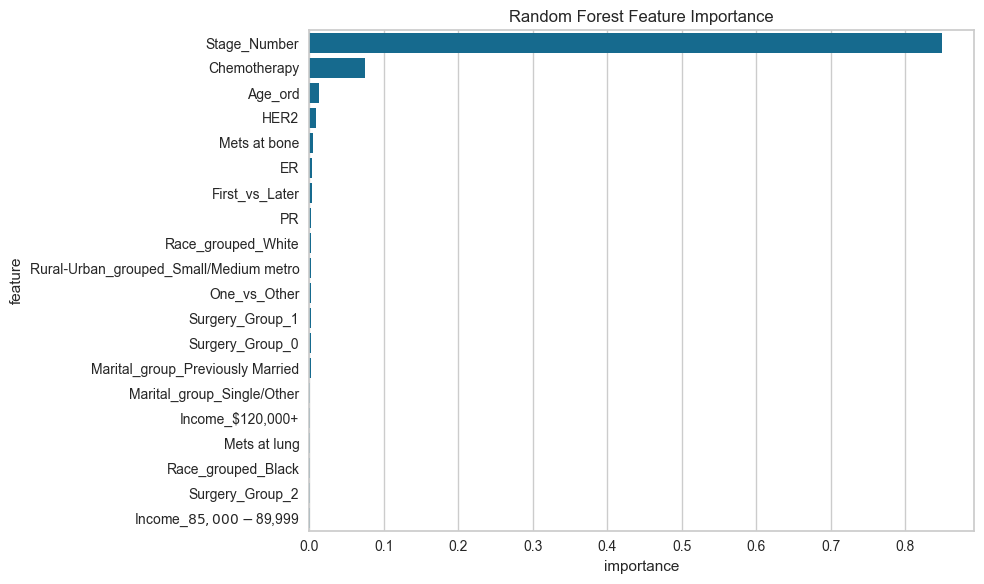

In [19]:
# ===============================
# Random Forest 직접 구현
# ===============================
# 1️⃣ 라이브러리 불러오기
# ===============================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, average_precision_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 2️⃣ 데이터 준비
# ===============================
# 범주형 변수 원-핫 인코딩 (RandomForest는 숫자형만 처리 가능)
X = pd.get_dummies(df[feature_cols], drop_first=True)
y = df['target'].copy()

# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# 3️⃣ Random Forest 학습
# ===============================
rf = RandomForestClassifier(
    n_estimators=500,        # 트리 개수 (많을수록 안정적)
    max_depth=None,          # 트리 깊이 제한 없음
    class_weight='balanced', # 클래스 불균형 고려
    random_state=42,
    n_jobs=-1                # CPU 병렬 처리
)

rf.fit(X_train, y_train)

# ===============================
# 4️⃣ 성능 평가
# ===============================
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("PR AUC (Average Precision):", average_precision_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

# ===============================
# 5️⃣ 변수 중요도
# ===============================
fi = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# 상위 20개 출력
print("\n=== Top 20 Important Features ===")
print(fi.head(20))

# 시각화
plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=fi.head(20))
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()


=== Top 20 Important Features (without Stage_Number) ===
                                   feature  importance
7                             Chemotherapy    0.075030
0                                  Age_ord    0.012942
5                                     HER2    0.009012
8                             Mets at bone    0.005746
3                                       ER    0.003831
13                          First_vs_Later    0.003464
4                                       PR    0.003199
16                      Race_grouped_White    0.003155
42  Rural-Urban_grouped_Small/Medium metro    0.002734
12                            One_vs_Other    0.002354
36                         Surgery_Group_1    0.002265
35                         Surgery_Group_0    0.002236
17        Marital_group_Previously Married    0.002081
18              Marital_group_Single/Other    0.001866
20                        Income_$120,000+    0.001656
11                            Mets at lung    0.001526
14     

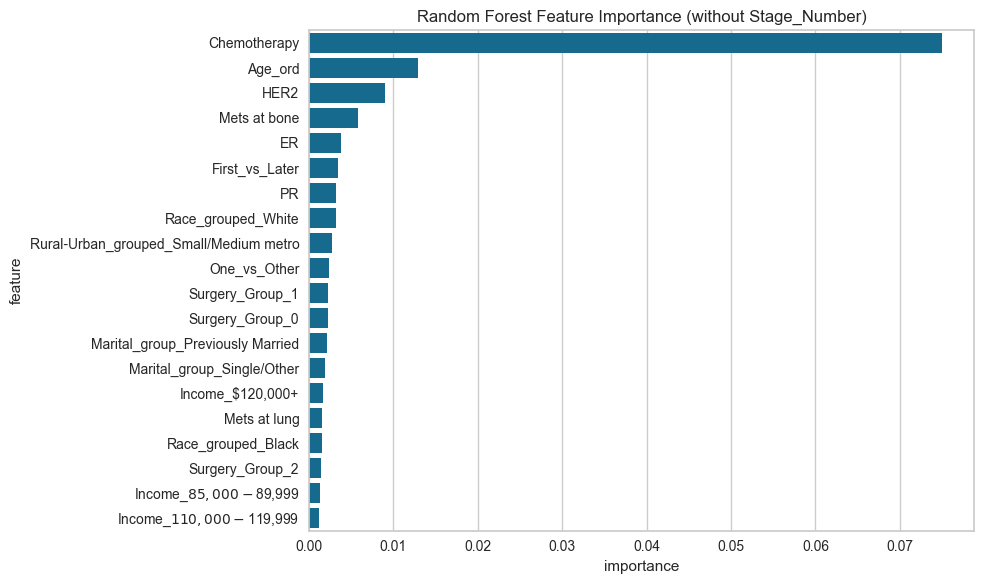

In [ ]:
## 제일 높은 Stage_Number 제외하고 Feature Importance(극단적으로 Stage_Number이 높아서 빼고 돌려보라는 교수님 추천)

if 'Stage_Number' in fi['feature'].values:
    fi_no_stage = (
        fi[fi['feature'] != 'Stage_Number']
        .sort_values('importance', ascending=False)
    )
else:
    # 혹시 원-핫 인코딩 과정 등으로 이름이 바뀐 경우를 대비해 유사 매칭
    mask = ~fi['feature'].str.contains(r'^Stage_Number$', case=False, regex=True)
    fi_no_stage = fi[mask].sort_values('importance', ascending=False)

# 2) 출력
print("\n=== Top 20 Important Features (without Stage_Number) ===")
print(fi_no_stage.head(20))

# 3) 시각화
plt.figure(figsize=(10,6))
sns.barplot(data=fi_no_stage.head(20), x='importance', y='feature')
plt.title('Random Forest Feature Importance (without Stage_Number)')
plt.tight_layout()
plt.show()


=== Confusion Matrix ===
[[72  0]
 [ 3 39]]


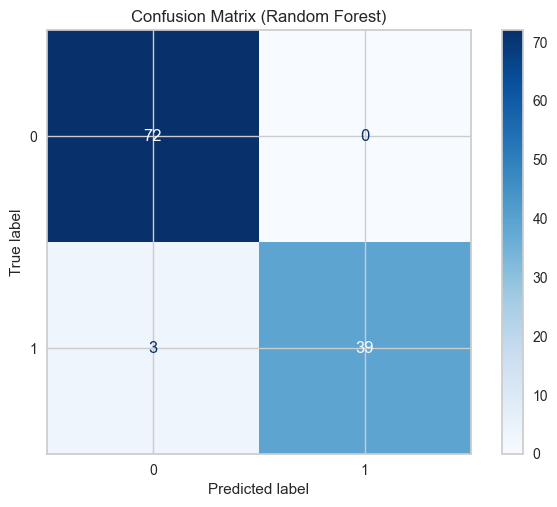

In [ ]:
#혼동행렬 시각화

#장점: 정상 환자를 잘못 암으로 오판하는 경우(FP)가 전혀 없음 → 불필요한 검사/치료 위험이 없음.
#단점: 암 환자 3명을 놓친 것(FN). 의료 분야에서는 FN이 치명적일 수 있으므로 Recall(민감도)을 더 끌어올리는 튜닝/모델링이 필요할 수 있음.
# ===============================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 혼동행렬 계산
cm = confusion_matrix(y_test, y_pred)

print("\n=== Confusion Matrix ===")
print(cm)

# 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues)   
plt.title("Confusion Matrix (Random Forest)")
plt.show()


In [ ]:
pip install optuna

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 60.1 MB/s eta 0:00:00

   --------------- ------------------------ 3/8 [greenlet]
   ------------------------- -------------- 5/8 [sqlalchemy]
   ------------------------- -------------- 5/8 [sqlalchemy]
   ------------------------- -------------- 5/8 [sqlalchemy]
   ------------------------- -------------- 5/8 [sqlalchemy]
   ------------------------- -------------- 5/8 [sqlalchemy]
   ----------------------------------- ---- 7/8 [optuna]
   ----------------------------------- ---- 7/8 [optuna]
   ----------------------------------- ---- 7/8 [optuna]
   ---------------------------------------- 8/8 [optuna]

Note: you may need to restart the kernel to use updated packages.


In [82]:
# ===============================
# 1) 피처/타깃 준비
# ===============================

# Behavior code 기반 target (malignant=1, in situ=0)
# target_bc는 이전에 만든 그대로 사용
y = df['target_bc'].copy()

# 필요하다면 Behavior code(원본)도 보존 가능
df['Behavior_code_bin'] = df['target_bc']

# 원본처럼 1=benign, 0=malignant 구조를 흉내내고 싶다면 (주의: 해석 반전)
# df['Behavior code'] = 1 - df['target_bc']

# ===============================
# 2) Optuna 학습용 피처(X) 만들기
# ===============================

# feature_cols는 이전 단계에서 정의한 컬럼 리스트 그대로 사용
X = df[feature_cols].copy()

print("X shape:", X.shape)
print("y 분포:", y.shape)

X shape: (309044, 21)
y 분포: (309044,)


In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    stratify = y, # 클래스 분포 비율 맞추기
                                                    random_state = 42)
print("train 데이터: ", X_train.shape)
print("test 데이터: ", X_test.shape)




train 데이터:  (247235, 21)
test 데이터:  (61809, 21)


In [85]:
print(pd.Series(y_train).value_counts())
print(pd.Series(y_train).value_counts(normalize=True))

target_bc
1    244171
0      3064
Name: count, dtype: int64
target_bc
1    0.987607
0    0.012393
Name: proportion, dtype: float64


In [92]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
#suggest_categorical 최적화 과정에서 더 좋은걸로 제안
def objective(trial):
    classifier_name = trial.suggest_categorical('classifier', ['SVC', 'RandomForest'])
    if classifier_name == 'SVC':
        svc_c = trial.suggest_float('svc_c', 0.0000000001, 10000000000, log=True)
        classifier_obj = svm.SVC(C=svc_c, gamma='auto')
    else:
        rf_max_depth = int(trial.suggest_float('rf_max_depth', 2, 32, log=True))
        classifier_obj = RandomForestClassifier(max_depth=rf_max_depth, n_estimators=10)


    accuracy = cross_val_score(classifier_obj, X_train, y_train, cv = 5).mean()
    return accuracy




In [94]:
import pandas as pd

# 원-핫 인코딩 (범주형 → 숫자)
X_enc = pd.get_dummies(X, drop_first=True)

# train/test split (인코딩된 데이터 사용!)
X_train_enc, X_test_enc, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, stratify=y, random_state=42
)

In [101]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    classifier_name = trial.suggest_categorical('classifier', ['SVC', 'RandomForest'])

    if classifier_name == 'SVC':
        svc_c = trial.suggest_float('svc_c', 1e-5, 1e5, log=True)
        classifier_obj = svm.SVC(C=svc_c, gamma='auto')
    else:
        rf_max_depth = trial.suggest_int('rf_max_depth', 2, 32)
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        classifier_obj = RandomForestClassifier(
            max_depth=rf_max_depth,
            n_estimators=n_estimators,
            random_state=42,
            n_jobs=-1
        )
        
    # ⬇️ 여기서 반드시 X_train_enc 사용
    score = cross_val_score(classifier_obj, X_train_enc, y_train, cv=3, scoring="roc_auc").mean()
    return score

In [ ]:
# 하이퍼파라미터 최적값=19

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)
print("Best params:", study.best_trial.params)
print("Best score:", study.be
      
      
      st_value)

[I 2025-08-31 14:40:10,944] A new study created in memory with name: no-name-50937cd7-06b0-4c6f-9174-d874d964c584
[I 2025-08-31 14:40:14,412] Trial 0 finished with value: 0.9994493511469345 and parameters: {'classifier': 'RandomForest', 'rf_max_depth': 24, 'n_estimators': 203}. Best is trial 0 with value: 0.9994493511469345.
[I 2025-08-31 14:40:18,962] Trial 1 finished with value: 0.9993834033158949 and parameters: {'classifier': 'RandomForest', 'rf_max_depth': 17, 'n_estimators': 272}. Best is trial 0 with value: 0.9994493511469345.
[I 2025-08-31 14:40:56,345] Trial 2 finished with value: 0.9992674890636192 and parameters: {'classifier': 'SVC', 'svc_c': 6189.77689938836}. Best is trial 0 with value: 0.9994493511469345.
[I 2025-08-31 14:40:58,490] Trial 3 finished with value: 0.999342156046566 and parameters: {'classifier': 'RandomForest', 'rf_max_depth': 7, 'n_estimators': 133}. Best is trial 0 with value: 0.9994493511469345.
[I 2025-08-31 14:41:00,838] Trial 4 finished with value: 0.

In [103]:
# ===============================
# 6) 최종 RandomForest 학습
# ===============================
best_params = study.best_trial.params
rf_final = RandomForestClassifier(
    max_depth=best_params['rf_max_depth'],
    n_estimators=best_params['n_estimators'],
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train_enc, y_train)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=20, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=96, n_jobs=-1,
                       oob_score=False, random_state=42, verbose=0,
                       warm_start=False)

In [109]:
# ===============================
# 7) Test set 평가
# ===============================
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, average_precision_score
import numpy as np

# 1) 반드시 "테스트셋"으로 예측하세요
y_pred = rf_final.predict(X_test_enc)

# 2) 확률 예측: 모델에 따라 분기 (RandomForest or SVC 등)
if hasattr(rf_final, "predict_proba"):
    y_proba_pos = rf_final.predict_proba(X_test_enc)[:, 1]  # 양성(1) 확률
elif hasattr(rf_final, "decision_function"):
    # SVC(probability=False) 같은 경우 decision_function 사용 → 확률 아님
    # ROC AUC는 점수(score)로 계산 가능
    scores = rf_final.decision_function(X_test_enc)
    # 스코어를 확률처럼 쓰지 말고, 바로 AUC에 사용
    y_proba_pos = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)  # 안정적 변환(선택)
else:
    raise AttributeError("rf_final에서 predict_proba/decision_function 둘 다 사용할 수 없습니다.")

# 3) 지표 계산 (이진분류)
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
roc_auc = roc_auc_score(y_test, y_proba_pos)               # 이진분류는 multi_class 옵션 X
pr_auc  = average_precision_score(y_test, y_proba_pos)     # PR AUC(불균형에서 유용)

print(f"Test Accuracy : {acc:.4f}")
print(f"Test macro-F1 : {f1_macro:.4f}")
print(f"Test ROC AUC  : {roc_auc:.6f}")
print(f"Test PR  AUC  : {pr_auc:.6f}")
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))



Test Accuracy : 0.9997
Test macro-F1 : 0.9935
Test ROC AUC  : 0.999921
Test PR  AUC  : 0.999999

Classification report:
               precision    recall  f1-score   support

           0     0.9770    0.9974    0.9871       766
           1     1.0000    0.9997    0.9998     61043

    accuracy                         0.9997     61809
   macro avg     0.9885    0.9985    0.9935     61809
weighted avg     0.9997    0.9997    0.9997     61809

